# Conduction Velocity Estimation with PINN

Reconstruct a local activation time (LAT) map and a conduction-speed field from
sparse samples on an atrial surface. We generate a synthetic reference map,
encode the anatomy with surface eigenfunctions, and fit two networks using
observations and an eikonal constraint.

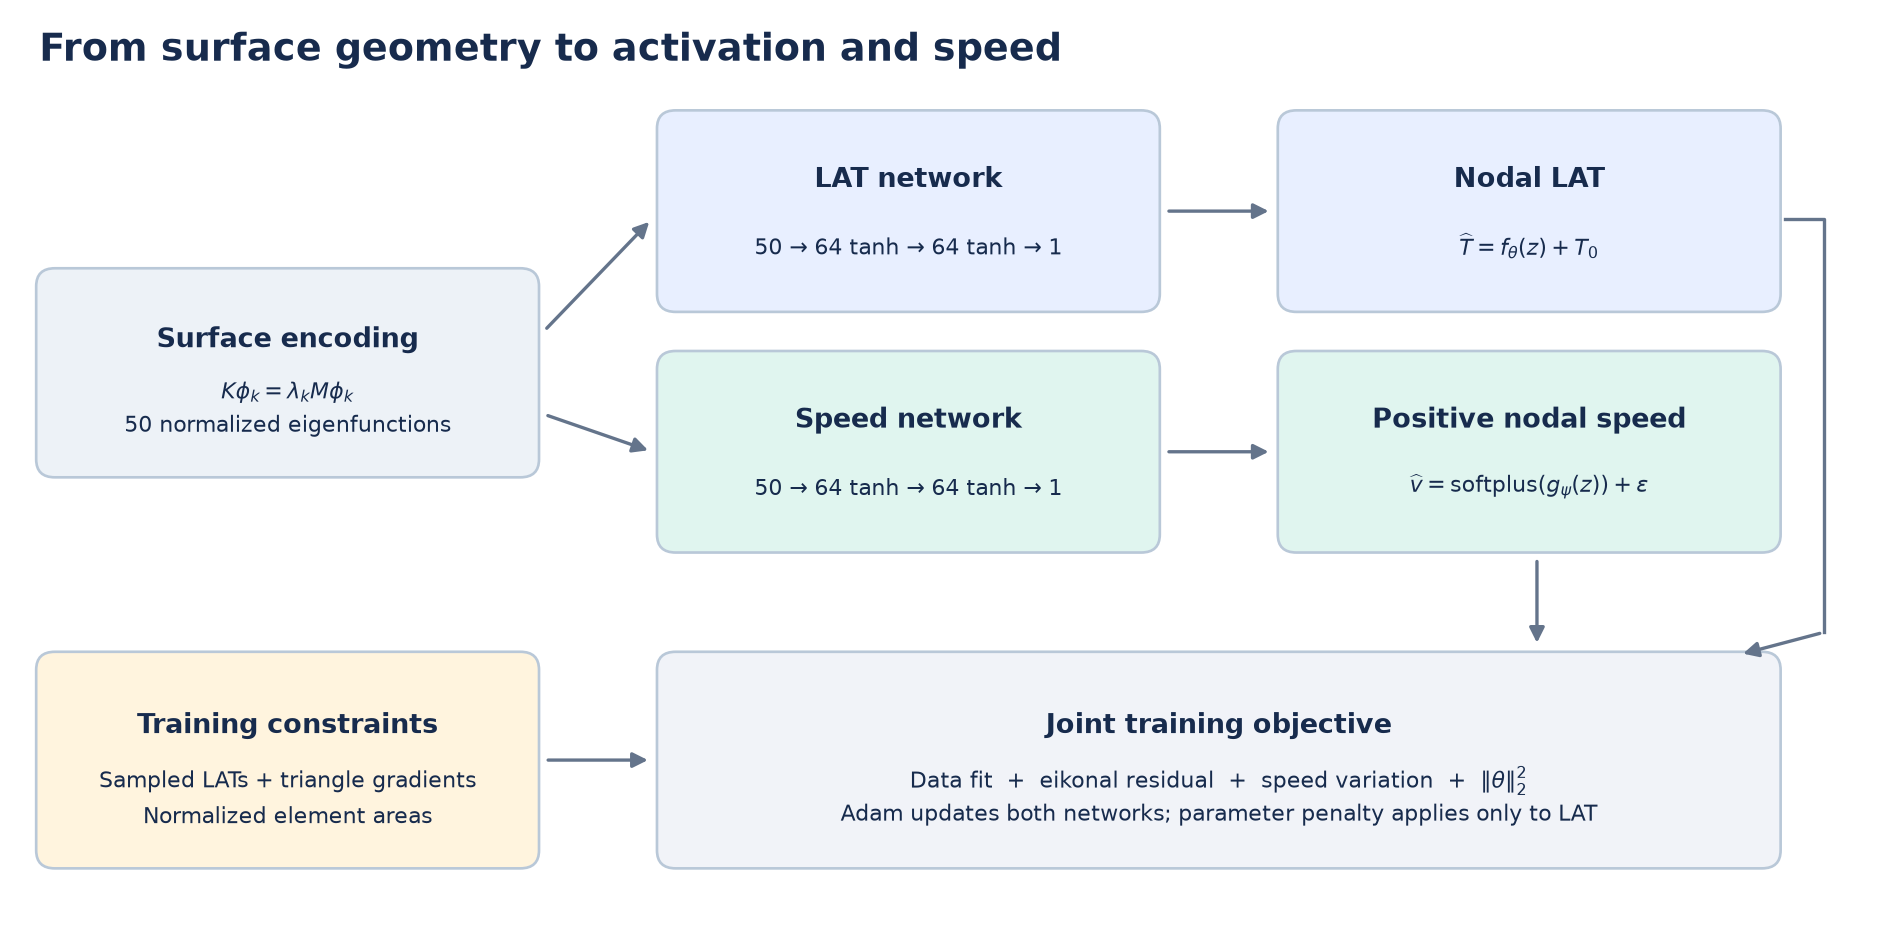

**Network overview.** Both networks use the same spectral features. Their outputs
are coupled by the eikonal loss; only the LAT network receives the parameter penalty.

## 1. Atrial geometry and conduction heterogeneity

### 1.1. Select the pacing site

The triangular mesh represents the atrial surface $\mathcal{S}$. Select a pacing
site and a second point defining the center of a reduced-conductivity region.


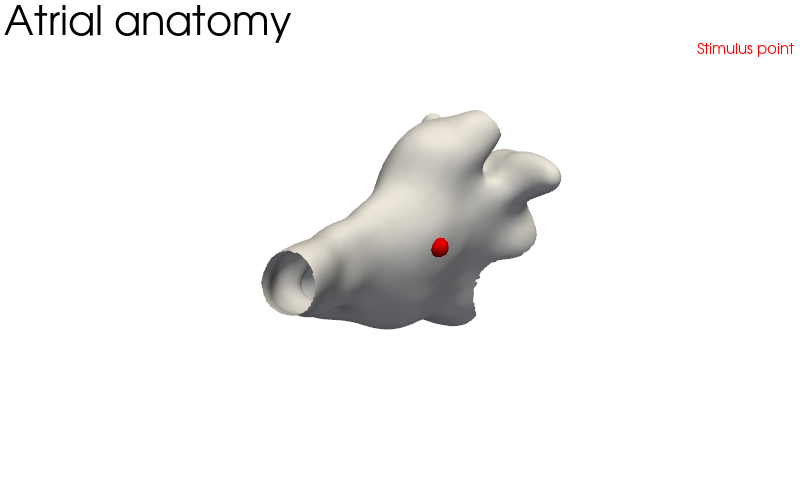

In [1]:
from pathlib import Path
import numpy as np
import pyvista as pv


path = Path("./data")

points = np.load(path / "atrial_points.npy")
elems = np.load(path / "atrial_elems.npy")

camera_position = [(-159.069, -285.733, 86.216),
                   (-33.103, -27.487, 75.834),
                   (-0.014, -0.033, -0.999)]

poly = pv.PolyData(points, np.hstack((np.full((elems.shape[0], 1), 3), elems)).astype(np.int64))

stim_point_id = 15419
low_cv_point_id = 12411

pv.set_jupyter_backend("static")
pl = pv.Plotter(window_size=(800, 500))
pl.set_background("white")
pl.add_text("Atrial anatomy", position="upper_left", font_size=16, color="black")
pl.add_mesh(poly, color="white", opacity=1., show_edges=False)
pl.add_points(points[stim_point_id], color="red", point_size=20,
              render_points_as_spheres=True, label="Stimulus point")
pl.add_legend([["Stimulus point", "red"]], bcolor="white", border=True, size=(0.15, 0.1))
pl.show()


**Figure 1.** Atrial surface with the pacing site in red.


### 1.2. Define a reduced-conductivity patch

Geodesic distance follows the surface rather than cutting through the atrial
cavity. Within a distance of 20 coordinate units from the selected center,
set the relative conductivity multiplier to 0.3; elsewhere it is 1. Element
multipliers are averages of their nodal values. This creates a region expected
to conduct more slowly, but the multiplier is not itself a conduction speed.


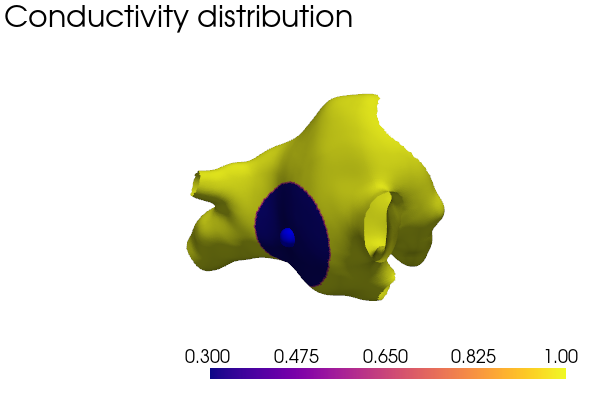

In [2]:
import finitewave_tools.linalg as fwl
import finitewave as fw

source_ids = np.array([low_cv_point_id])

spatial_discretization = fw.FiniteElementDiscretization()
spatial_discretization.reference_element = fw.LinearTriangleElement()
G = spatial_discretization.build_gradient_operator(points, elems, as_sparse=False)
K, M = spatial_discretization.build_system_matrices(points, elems)
elem_sizes = spatial_discretization.compute_element_sizes(points, elems)

geo_dist = fwl.geodesic_distance(K, M, G, elems, elem_sizes, source_ids,
                                 t=100, atol=1e-8, maxiter=1000)
low_cv_ids = geo_dist < 20

conductivity = np.ones(points.shape[0])
conductivity[low_cv_ids] = 0.3
elem_conductivity = np.mean(conductivity[elems], axis=1)

pl = pv.Plotter(window_size=(600, 400))
pl.set_background("white")
pl.add_text("Conductivity distribution", position="upper_left", font_size=16, color="black")
pl.add_mesh(poly, scalars=elem_conductivity, cmap="plasma", opacity=1., 
            show_edges=False, copy_mesh=True)
pl.add_points(points[low_cv_point_id], color="blue", point_size=20,
              render_points_as_spheres=True, label="Low CV point")
pl.camera_position = camera_position
pl.show()

**Figure 2.** Elementwise relative conductivity multiplier. The geodesic patch reduces conductivity to 30% of baseline.


## 2. Generate reference activation times

A Courtemanche-model simulation provides the reference LAT field $T(x)$.
Spatially separated surface samples serve as synthetic observations; only
these sampled LATs enter the training loss. The complete map is retained for
visual comparison. All sampled LATs must be finite and represent activated nodes.


Running Courtemanche on Triangle Elements:   0%|          | 0/12500 [00:00<?, ?it/s]

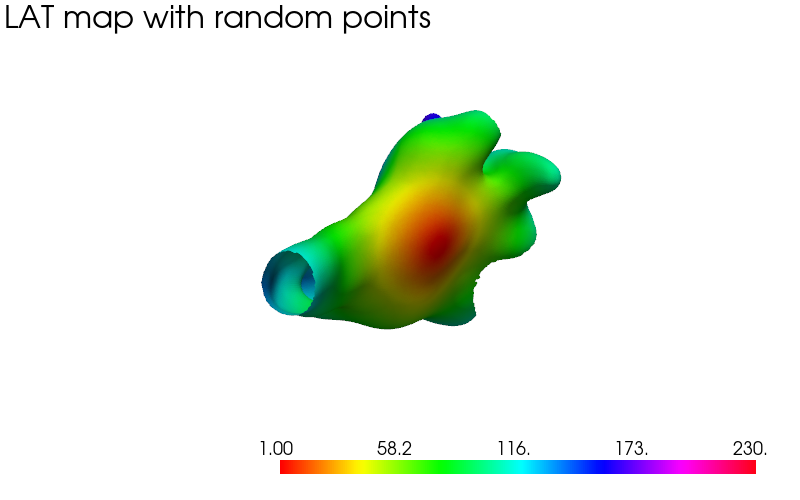

In [3]:
import finitewave as fw
from finitewave_tools.meshkit.points.point_sampler import select_random_points

cardiac_tissue = fw.CardiacTissue(coords=points, elems=elems,
                                  elem_type=fw.ElementType.TRIANGLE)
cardiac_tissue.conductivity = elem_conductivity

lat_tracker = fw.ActivationTimeTracker(step=50)

# create model object and set up parameters:
simulation = fw.CardiacSimulation(dt=0.02, t_max=250, backend="jax")
simulation.cardiac_tissue = cardiac_tissue
simulation.cardiac_model = fw.Courtemanche()
simulation.stim_sequence = fw.StimSequence()
simulation.stim_sequence.add_stim(
    fw.StimVoltageElectrodes(time=0, volt_value=1, coords=points[stim_point_id], size=3.0)
    )
simulation.time_integration = fw.BackwardEulerTimeIntegration(atol=1e-6)
simulation.tracker_sequence = fw.TrackerSequence()
simulation.tracker_sequence.add_tracker(lat_tracker)

# run the model:
simulation.run()

lats = lat_tracker.output

pv.set_jupyter_backend("static")
pl = pv.Plotter(window_size=(800, 500))
pl.set_background("white")
pl.add_text("LAT map with random points", position="upper_left", font_size=16, color="black")
pl.add_mesh(poly, scalars=lats, cmap="hsv", opacity=1., show_edges=False, copy_mesh=True)
pl.show()

**Figure 3.** Simulated reference LAT map.


## 3. Represent spatial variation on the surface

### 3.1. Tangential gradients

For linear triangles, the surface gradient is constant inside each element:

$$
\left.\nabla_{\mathcal S}T\right|_e=G_e\,\mathbf T_e,
$$

where $\mathbf T_e$ contains the three nodal LATs. The same FEM operator will
measure spatial variation in the predicted LAT and speed fields. A larger
LAT gradient indicates slower propagation under the isotropic eikonal model.


/Users/arstanbekokenov/Projects/miniconda3/envs/fibronn/lib/python3.12/site-packages/pyacvd/clustering.py:76: PyVistaDeprecationWarning: `PolyData._connectivity_array` is deprecated. Use `PolyData.face_connectivity` instead, which returns a read-only array.
  return cast(NDArray[U], mesh._connectivity_array.reshape(-1, 3))
/Users/arstanbekokenov/Projects/miniconda3/envs/fibronn/lib/python3.12/site-packages/pyacvd/clustering.py:619: PyVistaDeprecationWarning: `PolyData._connectivity_array` is deprecated. Use `PolyData.face_connectivity` instead, which returns a read-only array.
  faces = mesh._connectivity_array.reshape(-1, 3)


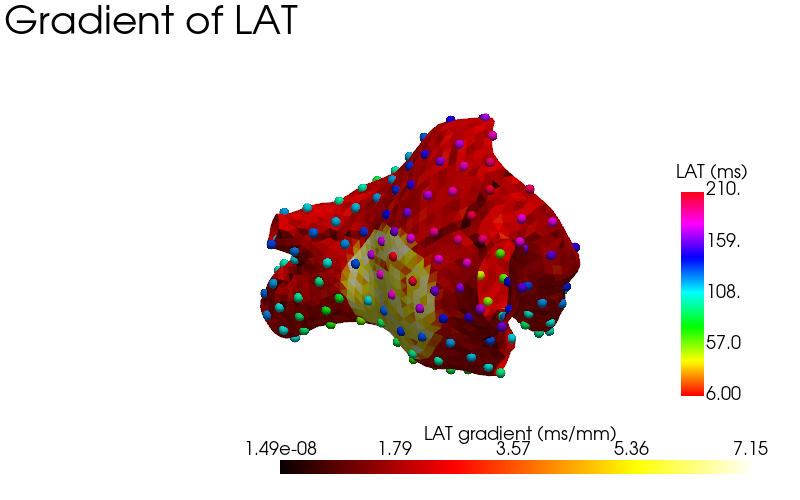

In [5]:
import jax
from scipy import spatial
import pyacvd
import finitewave as fw
from finitewave_tools.meshkit.points.point_sampler import select_random_points


def coarse_mesh(poly, target_num_points):
    surface = poly.triangulate().clean()
    clustering = pyacvd.Clustering(surface.copy())
    clustering.subdivide(3)
    clustering.cluster(target_num_points)
    remeshed = clustering.create_mesh()
    points = np.array(remeshed.points)
    elems = np.array(remeshed.face_connectivity).reshape(-1, 3)
    return points, elems


def find_closest_points(source_points, target_points):
    tree = spatial.cKDTree(target_points)
    _, closest_indices = tree.query(source_points)
    return closest_indices


@jax.jit
def compute_elem_grad(elem_grad_op, x_elem):
    return elem_grad_op @ x_elem


@jax.jit
def compute_gradients(G, x, elements):
    return jax.vmap(compute_elem_grad, in_axes=(0, 0))(G, x[elements])


coarse_points, coarse_elems = coarse_mesh(poly, target_num_points=2000)
coarse_lats = lats[find_closest_points(coarse_points, points)]
observed_ids = select_random_points(coarse_points, distance=7, seed=42)

spatial_discretization = fw.FiniteElementDiscretization()
spatial_discretization.reference_element = fw.LinearTriangleElement()
G = spatial_discretization.build_gradient_operator(coarse_points, coarse_elems, as_sparse=False)
K, M = spatial_discretization.build_system_matrices(coarse_points, coarse_elems)

elem_sizes = spatial_discretization.compute_element_sizes(coarse_points, coarse_elems)
lat_grads = compute_gradients(G, coarse_lats, coarse_elems)
lat_norms = np.linalg.norm(lat_grads, axis=1)
faces = np.pad(coarse_elems, ((0, 0), (1, 0)), mode='constant', constant_values=3)
coarse_poly = pv.PolyData(coarse_points, faces)

pv.set_jupyter_backend("static")
pl = pv.Plotter(window_size=(800, 500))
pl.set_background("white")
pl.add_text("Gradient of LAT", position="upper_left", font_size=16, color="black")
pl.add_mesh(coarse_poly, scalars=lat_norms, cmap="hot", opacity=1.,
            scalar_bar_args={"title": "LAT gradient (ms/mm)"},
            show_edges=False, copy_mesh=True)
pl.add_points(coarse_points[observed_ids], scalars=coarse_lats[observed_ids],
              point_size=10, render_points_as_spheres=True, label="Observed points",
              cmap="hsv",
              scalar_bar_args={"title": "LAT (ms)", "vertical": True,
                               "position_x": 0.85, "position_y": 0.2})
pl.camera_position = camera_position
pl.show()

**Figure 4.** Magnitude of the tangential LAT gradient on each triangle.
The colors show how rapidly activation time changes along the surface, not
propagation direction. Points correspond to data points used for training a PINN.


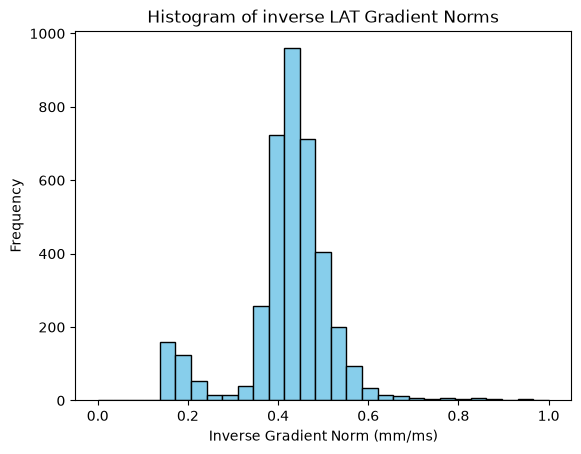

In [6]:
import matplotlib.pyplot as plt


plt.hist(1 / lat_norms, bins=np.linspace(0, 1, 30), color="skyblue", edgecolor="black")
plt.title("Histogram of inverse LAT Gradient Norms")
plt.xlabel("Inverse Gradient Norm (mm/ms)")
plt.ylabel("Frequency")
plt.show()

**Figure 5.** Distribution of the inverse tangential LAT gradient magnitude,
$1/\|\nabla_{\mathcal S}T\|$, across triangles of the coarse mesh. Under the
isotropic eikonal relation, these values estimate local conduction speed
in mm/ms from the reference LAT field.


### 3.2. Laplace–Beltrami features

Following the geometric encoding in [Δ-PINNs](https://arxiv.org/abs/2209.03984),
solve the surface eigenproblem and its finite-element discretization:

$$
-\Delta_{\mathcal S}\phi_k=\lambda_k\phi_k,
\qquad K\boldsymbol\phi_k=\lambda_kM\boldsymbol\phi_k.
$$

Here $K$ and $M$ describe the mesh geometry with unit diffusion. The network
input at node $i$ is $\mathbf z_i=(\phi_0(i),\ldots,\phi_{49}(i))$ after
columnwise normalization. **Eigenfunction values are the inputs; eigenvalues
identify spatial scales.** Low modes describe broad variation over the anatomy,
while higher modes resolve finer patterns.


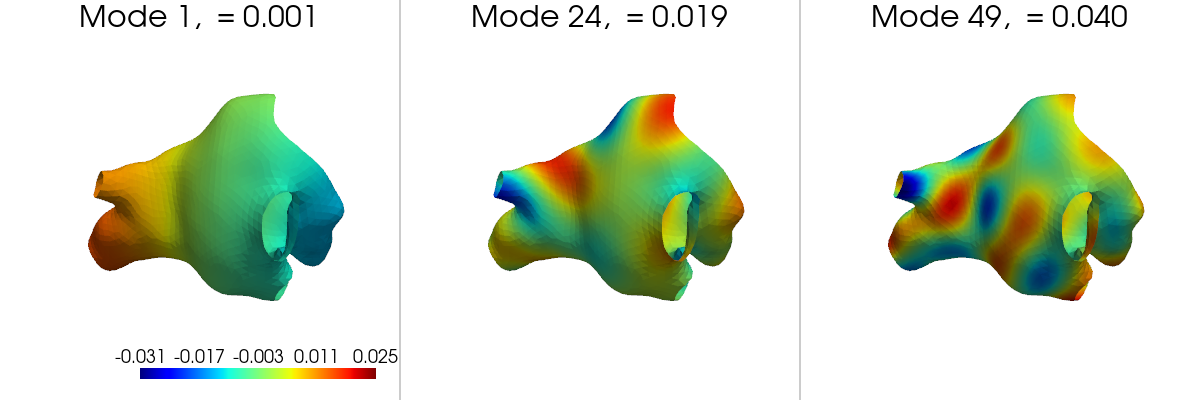

In [7]:
from scipy import sparse

N_EIGS = 50

eigvals, eigvecs = sparse.linalg.eigsh(K, k=N_EIGS, M=M, which='SM')

pl = pv.Plotter(shape=(1, 3), window_size=(1200, 400))

for i, idx in enumerate([1, 24, 49]):
    pl.subplot(0, i)
    pl.add_text(f"Mode {idx}, λ = {eigvals[idx]:.3f}", position="upper_edge",
                font_size=12,)
    pl.add_mesh(coarse_poly, scalars=eigvecs[:, idx], show_edges=False,
                scalar_bar_args={"fmt": "%.3f"}, cmap="jet")
pl.link_views()
pl.camera_position = camera_position
pl.show()

**Figure 6.** Three selected Laplace–Beltrami eigenfunctions. Panel titles
show the mode index and eigenvalue; colors indicate signed eigenfunction
amplitude, not activation time. Eigenfunction signs are arbitrary.


## 4. Learn activation time and conduction speed

### 4.1. Physical model and loss

Two networks predict $\widehat T_i=f_\theta(\mathbf z_i)+T_0$ and
$\widehat v_i=\operatorname{softplus}(g_\psi(\mathbf z_i))+\epsilon$.
The offset $T_0$ is the mean observed LAT; the speed is positive.

The isotropic eikonal relation is

$$
v\,\|\nabla_{\mathcal S}T\|=1.
$$

We follow the activation-time/speed formulation and regularization ideas in
[Physics-Informed Neural Networks for Cardiac Activation Mapping](https://www.frontiersin.org/journals/physics/articles/10.3389/fphy.2020.00042/full),
using FEM gradients and spectral inputs here. This tutorial uses one pair of
networks, without the paper's uncertainty ensemble or active-learning procedure.

Let $\mathcal O$ be the observed nodes, $w_e=A_e/\sum_j A_j$ the normalized
triangle areas, and $\bar v_e$ the mean predicted nodal speed in triangle $e$.
The total loss is

$$
\begin{aligned}
\mathcal L={}&\gamma_d\frac{1}{|\mathcal O|}
 \sum_{i\in\mathcal O}(\widehat T_i-T_i)^2\\
&+\gamma_e\sum_e w_e\bigl(1-\bar v_e\|G_e\widehat{\mathbf T}_e\|\bigr)^2\\
&+\gamma_r\sum_e w_e\|G_e\widehat{\mathbf v}_e\|
 +\gamma_\theta\|\theta\|_2^2.
\end{aligned}
$$

The terms fit observations, encourage eikonal consistency, penalize spatial
variation in speed, and shrink LAT-network weights and biases. The fixed offset
and speed-network parameters are excluded from the last term. Area weighting
balances elements of different sizes; the code adds a small stabilizer inside
gradient norms.


In [119]:
from typing import NamedTuple

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from flax import nnx
import optax
from tqdm.auto import tqdm


class MLP(nnx.Module):
    def __init__(self, din, dmid, dout=1, *, positive=False, offset=0.0, rngs):
        dims = [din] + dmid
        self.layers = nnx.List([
            nnx.Linear(in_dim, out_dim, rngs=rngs)
            for in_dim, out_dim in zip(dims[:-1], dims[1:])
        ])
        self.output_layer = nnx.Linear(dmid[-1], dout, rngs=rngs)
        self.positive = positive
        self.offset = offset

    def __call__(self, x):
        for layer in self.layers:
            x = nnx.tanh(layer(x))
        x = self.output_layer(x)
        return nnx.softplus(x) + 1e-6 if self.positive else x + self.offset


class MeshData(NamedTuple):
    features: jax.Array
    grad_operator: jax.Array
    elements: jax.Array
    area_weights: jax.Array


class Observations(NamedTuple):
    indexes: jax.Array
    lats: jax.Array


class LossWeights(NamedTuple):
    data: float = 0.01
    eikonal: float = 1.0
    reg: float = 10.0
    theta: float = 1e-4


@jax.jit
def compute_data_loss(prediction, target):
    return jnp.mean(jnp.square(prediction - target))


@jax.jit
def compute_grad_norms(grad_operator, values, elements):
    # G[e] @ values[elements[e]] gives one physical vector per triangle.
    grads = jnp.einsum("eij,ej->ei", grad_operator, values[elements])
    return jnp.sqrt(jnp.sum(jnp.square(grads), axis=-1) + 1e-8)


@jax.jit
def compute_eikonal_loss(lat, speed, grad_operator, elements, area_weights):
    lat_grad_norms = compute_grad_norms(grad_operator, lat, elements)
    element_speed = jnp.mean(speed[elements], axis=1)
    return jnp.sum(area_weights * jnp.square(1.0 - element_speed * lat_grad_norms))


@jax.jit
def compute_reg_loss(speed, grad_operator, elements, area_weights):
    speed_grad_norms = compute_grad_norms(grad_operator, speed, elements)
    return jnp.sum(area_weights * speed_grad_norms)


def compute_theta_loss(lat_model):
    """Squared L2 norm of LAT-network trainable weights and biases."""
    parameters = jax.tree_util.tree_leaves(nnx.state(lat_model, nnx.Param))
    return sum(jnp.sum(jnp.square(parameter)) for parameter in parameters)

def loss_fn(lat_model, v_model, mesh, observations, weights):
    lat = lat_model(mesh.features).squeeze(-1)
    speed = v_model(mesh.features).squeeze(-1)

    data_loss = compute_data_loss(lat[observations.indexes], observations.lats)
    eikonal_loss = compute_eikonal_loss(
        lat, speed, mesh.grad_operator, mesh.elements, mesh.area_weights)
    reg_loss = compute_reg_loss(
        speed, mesh.grad_operator, mesh.elements, mesh.area_weights)
    theta_loss = compute_theta_loss(lat_model)
    total_loss = (weights.data * data_loss + weights.eikonal * eikonal_loss
                  + weights.reg * reg_loss + weights.theta * theta_loss)
    metrics = {
        "total_loss": total_loss,
        "data_loss": weights.data * data_loss,
        "eikonal_loss": weights.eikonal * eikonal_loss,
        "reg_loss": weights.reg * reg_loss,
        "theta_loss": weights.theta * theta_loss,
    }
    return total_loss, metrics


@nnx.jit
def train_step(lat_model, lat_optimizer, v_model, v_optimizer,
               mesh, observations, weights):
    (loss, metrics), (lat_grads, v_grads) = nnx.value_and_grad(
        loss_fn, argnums=(0, 1), has_aux=True
    )(lat_model, v_model, mesh, observations, weights)
    lat_optimizer.update(lat_model, lat_grads)
    v_optimizer.update(v_model, v_grads)
    return loss, metrics


### 4.2. Prepare observations and geometry

Normalize each eigenfunction across mesh nodes; LATs retain their original
units. Group geometry, measured LATs, and loss coefficients into `MeshData`,
`Observations`, and `LossWeights`. The supplied conductivity map is used for the
reference simulation, not as a target for the speed network.


In [122]:
lat_values = np.asarray(coarse_lats).reshape(-1)
elements_np = np.asarray(coarse_elems, dtype=np.int32)
features_np = np.asarray(eigvecs, dtype=np.float32)

# Normalize spectral inputs without using unobserved LATs.
feature_mean = features_np.mean(axis=0, keepdims=True)
feature_scale = features_np.std(axis=0, keepdims=True)
feature_scale = np.where(feature_scale > 1e-6, feature_scale, 1.0)
features = jnp.asarray((features_np - feature_mean) / feature_scale)
elements = jnp.asarray(elements_np)
grad_op = jnp.asarray(G, dtype=features.dtype)
ind_data = jnp.asarray(observed_ids, dtype=jnp.int32)
lat_target = jnp.asarray(lat_values[observed_ids], dtype=features.dtype)

triangle_points = np.asarray(points)[elements_np]
areas = np.asarray(elem_sizes)
area_weights = jnp.asarray(areas / areas.sum(), dtype=features.dtype)

# Named tuples are JAX PyTrees; create the input containers once.
mesh_data = MeshData(features, grad_op, elements, area_weights)
observations = Observations(ind_data, lat_target)

### 4.3. Optimize both networks

Adam updates the LAT and speed networks together for 10,000 epochs. The four
coefficients in `LossWeights` control the data–physics–regularization balance.
For example, `LossWeights(theta=0)` disables the LAT parameter penalty while
retaining the other default coefficients.


  0%|          | 0/10000 [00:00<?, ?it/s]

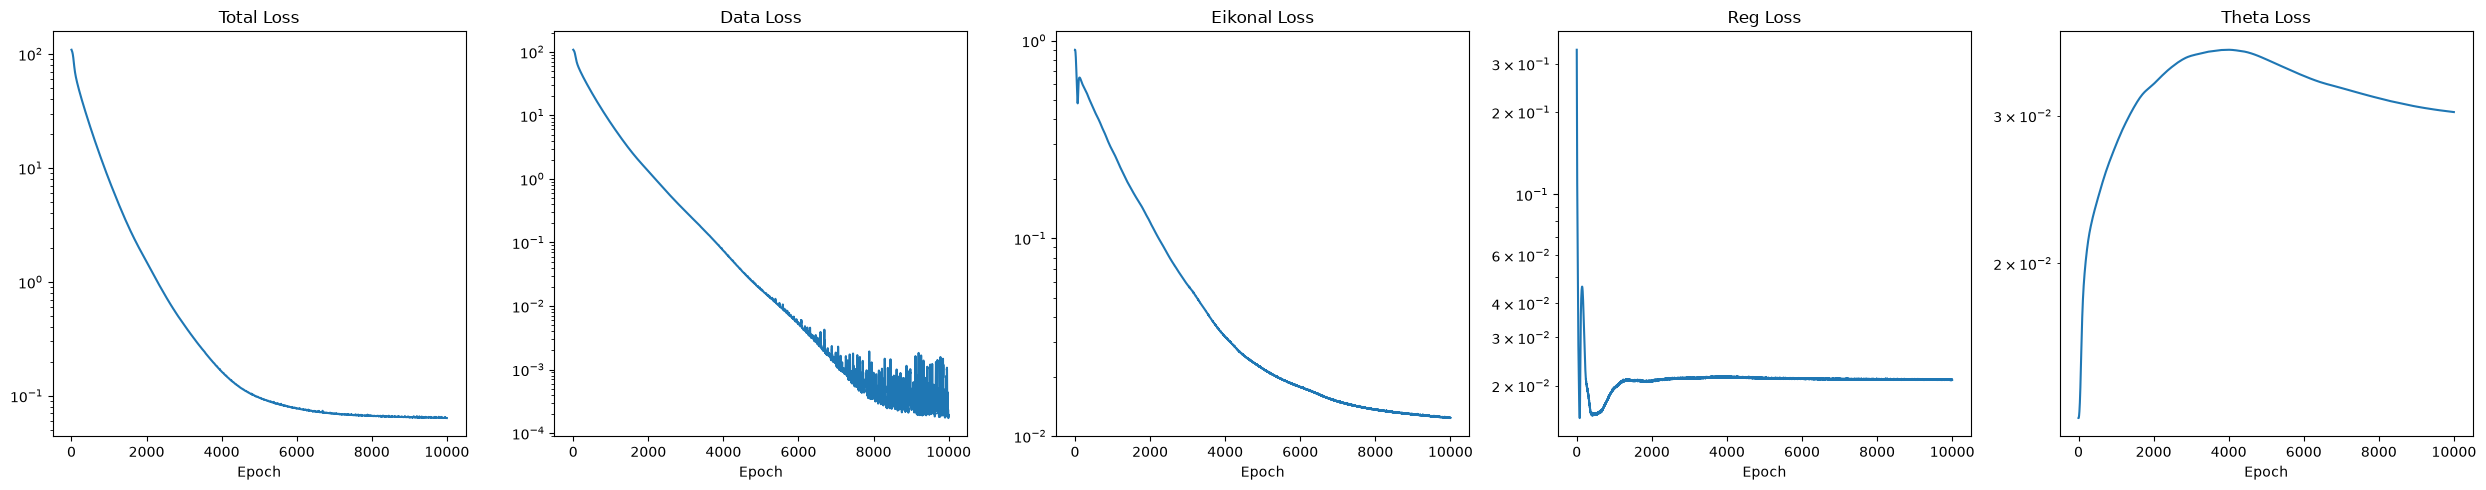

In [123]:
lat_offset = float(np.mean(lat_values[observed_ids]))
lat_model = MLP(features.shape[1], [64, 64], offset=lat_offset, rngs=nnx.Rngs(0))
v_model = MLP(features.shape[1], [64, 64], positive=True, rngs=nnx.Rngs(1))

lat_optimizer = nnx.Optimizer(lat_model, optax.adam(learning_rate=1e-3), wrt=nnx.Param)
v_optimizer = nnx.Optimizer(v_model, optax.adam(learning_rate=1e-3), wrt=nnx.Param)

loss_weights = LossWeights(data=0.05, eikonal=1.0, reg=10.0, theta=1e-4)

n_epochs = 10000
history = {name: [] for name in ("total_loss", "data_loss", "eikonal_loss", "reg_loss", "theta_loss")}

for _ in tqdm(range(n_epochs)):
    loss, metrics = train_step(lat_model, lat_optimizer, v_model, v_optimizer,
                               mesh_data, observations, loss_weights)
    metrics = jax.device_get(metrics)

    if not all(np.isfinite(value) for value in metrics.values()):
        raise FloatingPointError("Training produced a nonfinite loss.")

    for name, value in metrics.items():
        history[name].append(float(value))

fig, axs = plt.subplots(1, len(history), figsize=(5 * len(history), 5))
for ax, (name, values) in zip(axs, history.items()):
    ax.plot(values)
    ax.set_title(name.replace("_", " ").title())
    ax.set_xlabel("Epoch")
    ax.set_yscale("log")
fig.tight_layout()
plt.show()

**Figure 7.** Total loss and its four weighted components on logarithmic
axes. These curves diagnose optimization and the relative contribution of each
term; decreasing loss alone does not establish reconstruction accuracy.


## 5. Assess the reconstruction

### 5.1. Fit at sampled locations

The reported error is

$$
\mathrm{RMSE}_{\mathcal O}=\sqrt{\frac{1}{|\mathcal O|}
\sum_{i\in\mathcal O}(\widehat T_i-T_i)^2}.
$$

This measures training-data fit, not accuracy at unobserved locations. The full
simulated LAT map permits a separate comparison away from the samples.


In [124]:
# Predictions remain nodal arrays; preserve the LAT array's original shape.
predicted_lats = np.asarray(jax.device_get(
    lat_model(features).squeeze(-1))).reshape(coarse_points.shape[0])
predicted_v = np.asarray(jax.device_get(
    v_model(features).squeeze(-1))).reshape(coarse_points.shape[0])

observed_error = predicted_lats.reshape(-1)[ind_data] - coarse_lats[observed_ids]
print(f"Observed LAT RMSE: {np.sqrt(np.mean(observed_error**2)):.4f}")


Observed LAT RMSE: 0.0615


### 5.2. Compare spatial maps

Compare the reference and predicted LAT patterns, especially away from the
black observation markers. Interpret the speed map as an inferred field:
sparse LATs and an approximate eikonal model do not uniquely determine it.
The isotropic model does not explicitly describe pacing dynamics or wave
collisions. Speed units are mesh-coordinate units per LAT time unit.


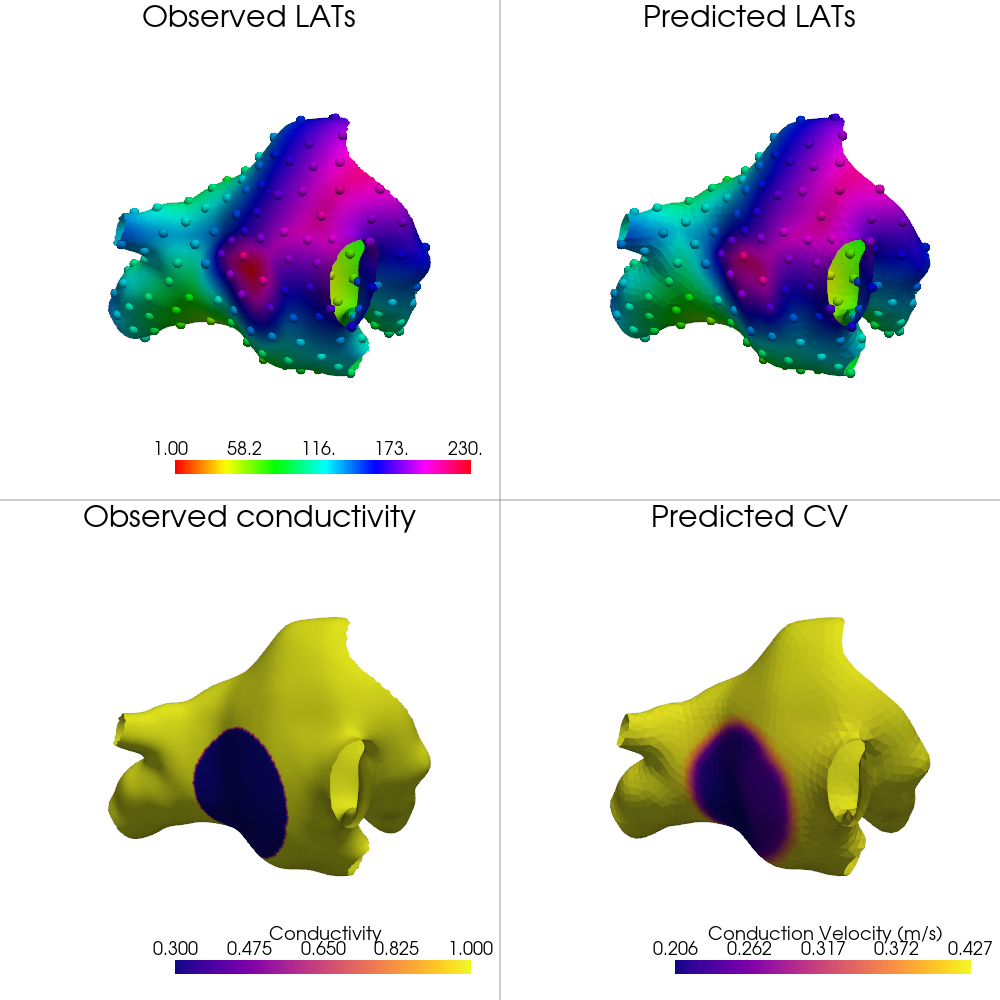

In [125]:
pv.set_jupyter_backend("static")
pl = pv.Plotter(shape=(2, 2), window_size=(1000, 1000))
pl.subplot(0, 0)
pl.add_text("Observed LATs", position="upper_edge", font_size=12)
pl.add_mesh(poly, scalars=lats, cmap="hsv", opacity=1., show_edges=False)
pl.add_points(coarse_points[observed_ids], scalars=coarse_lats[observed_ids],
              cmap="hsv", point_size=10, render_points_as_spheres=True)
pl.subplot(0, 1)
pl.add_text("Predicted LATs", position="upper_edge", font_size=12)
pl.add_mesh(coarse_poly, scalars=predicted_lats, cmap="hsv", opacity=1., show_edges=False)
pl.add_points(coarse_points[observed_ids], scalars=predicted_lats[observed_ids],
              cmap="hsv", point_size=10, render_points_as_spheres=True)
pl.subplot(1, 0)
pl.add_text("Observed conductivity", position="upper_edge", font_size=12)
pl.add_mesh(poly, scalars=elem_conductivity, cmap="plasma", opacity=1., show_edges=False,
            scalar_bar_args={"title": "Conductivity", "fmt": "%.3f"})
pl.subplot(1, 1)
pl.add_text("Predicted CV", position="upper_edge", font_size=12)
pl.add_mesh(coarse_poly, scalars=predicted_v, cmap="plasma", opacity=1., show_edges=False,
            scalar_bar_args={"title": "Conduction Velocity (m/s)", "fmt": "%.3f"})
pl.link_views()
pl.camera_position = camera_position
pl.show()

**Figure 8.** Top: full simulated LAT reference and predicted LAT, with observed
sites marked in black. Bottom: the prescribed conductivity multiplier and the
inferred conduction speed. The bottom panels have different meanings and units;
compare the location of slow regions, not their numerical color values.


## 6. References

1. Sahli Costabal, F., Pezzuto, S., and Perdikaris, P. (2024).
   **Δ-PINNs: Physics-informed neural networks on complex geometries.**
   *Engineering Applications of Artificial Intelligence*, 127, 107324.
   [Published article](https://doi.org/10.1016/j.engappai.2023.107324) ·
   [Open preprint](https://arxiv.org/abs/2209.03984).
   Basis for using Laplace–Beltrami eigenfunctions as geometric features.

2. Sahli Costabal, F., Yang, Y., Perdikaris, P., Hurtado, D. E., and Kuhl, E. (2020).
   **Physics-Informed Neural Networks for Cardiac Activation Mapping.**
   *Frontiers in Physics*, 8, 42.
   [Open article](https://www.frontiersin.org/journals/physics/articles/10.3389/fphy.2020.00042/full).
   Basis for joint LAT/speed estimation using eikonal and regularization losses.
